# Unemployment Analysis with Python
### Project Objective

The objective of this project is to analyze unemployment trends in India using Python. The analysis focuses on understanding regional and temporal variations in unemployment rates and evaluating the impact of the COVID-19 pandemic on employment across different states.

Using Python libraries such as Pandas, Matplotlib, and Seaborn, the project performs data cleaning, exploratory data analysis (EDA), and visualization to uncover meaningful insights from the unemployment dataset.

---

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

### Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Inspection
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Regional Analysis
7. Monthly Trend Analysis
8. Time-Series Visualization
9. Correlation Analysis
10. COVID-19 Impact Analysis
11. Conclusion

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Setting plot styles
plt.style.use("ggplot")
sns.set_palette("Set2")

## Importing Required Libraries

The first step is importing the necessary Python libraries.

- **Pandas** is used for data manipulation and analysis.
- **NumPy** is used for numerical computations.
- **Matplotlib** is used to create basic visualizations.
- **Seaborn** provides attractive statistical graphics.

In [4]:
# Loading the dataset

df = pd.read_csv("Unemployment in India.csv")

## Loading the Dataset

The unemployment dataset is loaded into a Pandas DataFrame using the `read_csv()` function.

This dataset contains unemployment statistics for different Indian states over multiple months, along with employment and labour participation information.

In [5]:
# Display first five rows

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Verify updated column names
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [7]:
df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "LabourParticipation"
}, inplace=True)

## Dataset Preview

The first five records are displayed to understand the structure of the dataset and the available columns.

In [8]:
# Display last five rows

df.tail()

,Region,Date,Frequency,Unemployment,Employed,LabourParticipation,Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Last Five Records

Displaying the last five rows helps verify that the dataset has been loaded correctly and provides an overview of the ending entries.

In [9]:
# Shape of dataset

df.shape

(768, 7)

## Dataset Shape

The shape of the dataset indicates:

- Number of rows (observations)
- Number of columns (features)

Understanding the dataset size helps estimate the amount of information available for analysis.

In [10]:
# Display column names

df.columns

Index(['Region', 'Date', 'Frequency', 'Unemployment', 'Employed',
       'LabourParticipation', 'Area'],
      dtype='object')

## Column Names

The dataset contains multiple columns representing:

- Region
- Date
- Frequency
- Estimated Unemployment Rate
- Estimated Employment
- Labour Participation Rate
- Area (Urban/Rural)

These variables will be used throughout the analysis.

In [11]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Region               740 non-null    object 
 1   Date                 740 non-null    object 
 2   Frequency            740 non-null    object 
 3   Unemployment         740 non-null    float64
 4   Employed             740 non-null    float64
 5   LabourParticipation  740 non-null    float64
 6   Area                 740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


## Dataset Information

The `info()` function provides:

- Number of entries
- Data types of each column
- Non-null values
- Memory usage

This helps identify whether any columns require type conversion or cleaning.

In [12]:
# Checking missing values

df.isnull().sum()

Region                 28
Date                   28
Frequency              28
Unemployment           28
Employed               28
LabourParticipation    28
Area                   28
dtype: int64

## Missing Value Analysis

Missing values can negatively affect analysis and visualization.

This step identifies whether any columns contain null values that need to be handled before further processing.

In [13]:
# Checking duplicate records

df.duplicated().sum()

np.int64(27)

## Duplicate Records

Duplicate rows may lead to biased analysis.

The dataset is checked for duplicate entries before performing any statistical calculations.

In [14]:
# Remove duplicates if present

df.drop_duplicates(inplace=True)

In [15]:
# Summary statistics

df.describe()

,Unemployment,Employed,LabourParticipation
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## Statistical Summary

The `describe()` function provides summary statistics for all numerical columns, including:

- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

These statistics help understand the overall distribution of the data.

In [16]:
# Removing extra spaces from column names

df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Unemployment', 'Employed',
       'LabourParticipation', 'Area'],
      dtype='object')

## Cleaning Column Names

Extra spaces in column names are removed to make referencing columns easier during analysis.

In [18]:
# Renaming lengthy column names

df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "LabourParticipation"
}, inplace=True)

df.columns

Index(['Region', 'Date', 'Frequency', 'Unemployment', 'Employed',
       'LabourParticipation', 'Area'],
      dtype='object')

In [19]:
# Convert Date column into datetime format

df["Date"] = pd.to_datetime(df["Date"])

In [20]:
# Extract month and year

df["Month"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year

df.head()

,Region,Date,Frequency,Unemployment,Employed,LabourParticipation,Area,Month,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019.0
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019.0
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019.0
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019.0
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019.0


In [21]:
# Checking data types after preprocessing

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 741 entries, 0 to 753
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Region               740 non-null    object        
 1   Date                 740 non-null    datetime64[ns]
 2   Frequency            740 non-null    object        
 3   Unemployment         740 non-null    float64       
 4   Employed             740 non-null    float64       
 5   LabourParticipation  740 non-null    float64       
 6   Area                 740 non-null    object        
 7   Month                740 non-null    object        
 8   Year                 740 non-null    float64       
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 57.9+ KB


## Final Dataset Inspection

After preprocessing:

- Column names have been cleaned.
- Date format has been converted.
- Month and Year features have been created.
- The dataset is now ready for Exploratory Data Analysis (EDA).

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the unemployment dataset through statistical summaries and visualizations.

The objectives of this analysis are to:

- Study the distribution of unemployment rates.
- Detect outliers.
- Compare unemployment across different states.
- Analyze monthly unemployment trends.
- Compare Urban and Rural unemployment.
- Identify the top states with the highest unemployment.
- Examine relationships among employment indicators.

In [22]:
# Display first few rows before analysis

df.head()

,Region,Date,Frequency,Unemployment,Employed,LabourParticipation,Area,Month,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019.0
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019.0
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019.0
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019.0
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019.0


## Dataset Ready for Analysis

The dataset has been successfully cleaned and preprocessed.

The following exploratory analysis will help identify important trends and patterns in unemployment across India.

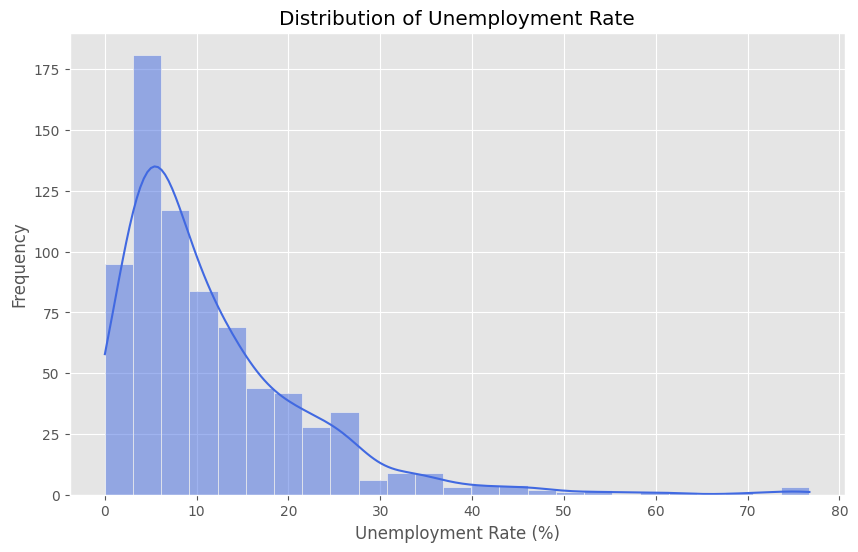

In [23]:
# Distribution of unemployment rate

plt.figure(figsize=(10,6))

sns.histplot(df["Unemployment"], bins=25, kde=True, color="royalblue")

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")

plt.show()

## Observation

The histogram shows how unemployment rates are distributed across the dataset.

Most observations are concentrated within a moderate range, while a few states experienced significantly higher unemployment rates, indicating the presence of extreme values.

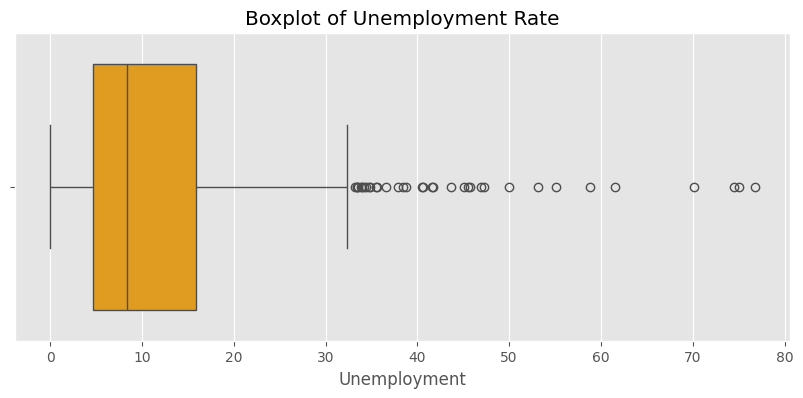

In [24]:
# Boxplot

plt.figure(figsize=(10,4))

sns.boxplot(x=df["Unemployment"], color="orange")

plt.title("Boxplot of Unemployment Rate")

plt.show()

In [25]:
# Region-wise average unemployment

region_avg = df.groupby("Region")["Unemployment"].mean().sort_values()

In [26]:
region_avg

Region
Meghalaya            4.798889
Odisha               5.657857
Assam                6.428077
Uttarakhand          6.582963
Gujarat              6.663929
Karnataka            6.676071
Sikkim               7.249412
Madhya Pradesh       7.406429
Andhra Pradesh       7.477143
Maharashtra          7.557500
Telangana            7.737857
West Bengal          8.124643
Chhattisgarh         9.240357
Goa                  9.274167
Tamil Nadu           9.284286
Kerala              10.123929
Puducherry          10.215000
Punjab              12.031071
Uttar Pradesh       12.551429
Rajasthan           14.058214
Chandigarh          15.991667
Jammu & Kashmir     16.188571
Delhi               16.495357
Himachal Pradesh    18.540357
Bihar               18.918214
Jharkhand           20.585000
Haryana             26.283214
Tripura             28.350357
Name: Unemployment, dtype: float64

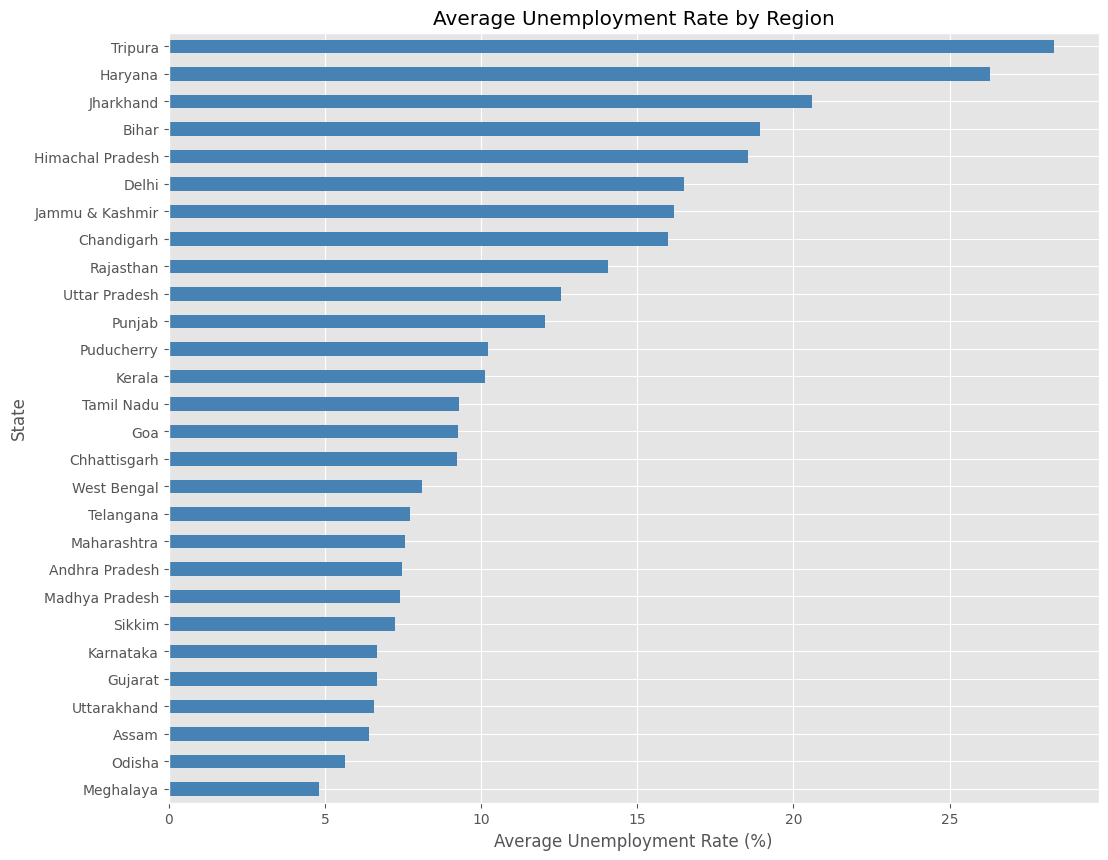

In [27]:
plt.figure(figsize=(12,10))

region_avg.plot(kind="barh", color="steelblue")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

In [28]:
# Top 10 states with highest unemployment

top10 = df.groupby("Region")["Unemployment"].mean().sort_values(ascending=False).head(10)

top10

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment, dtype: float64

## Top 10 States

The following analysis identifies the ten states with the highest average unemployment rates.

C:\Users\khush\AppData\Local\Temp\ipykernel_4968\1423559619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


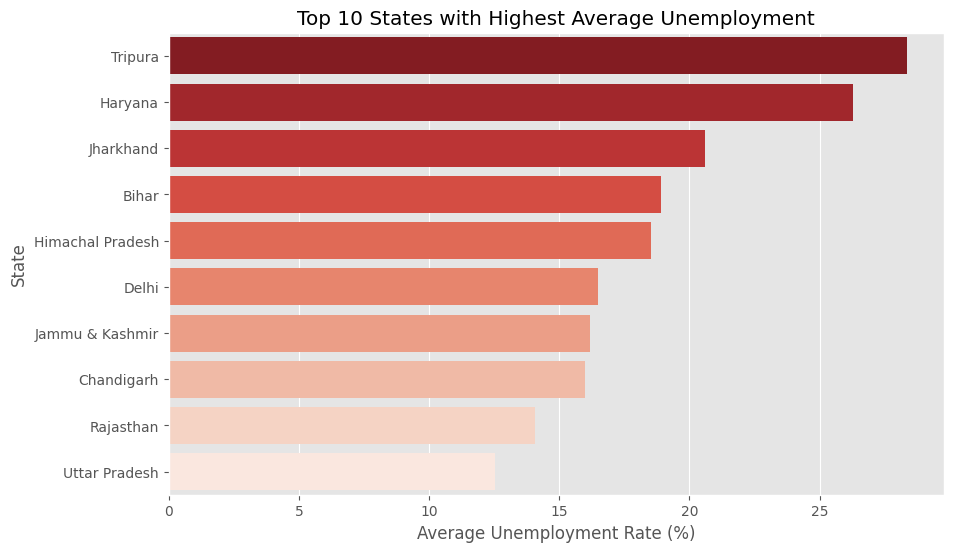

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="Reds_r"
)

plt.title("Top 10 States with Highest Average Unemployment")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

## Observation

These states consistently experienced the highest unemployment rates during the observation period.

The findings indicate that employment challenges vary considerably across different regions of India.

In [30]:
# Monthly unemployment trend

monthly = df.groupby("Month")["Unemployment"].mean()

months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = monthly.reindex(months)

monthly

Month
January       9.950755
February      9.964717
March        10.700577
April        23.641569
May          16.646190
June         10.553462
July          9.033889
August        9.637925
September     9.051731
October       9.900909
November      9.868364
December      9.497358
Name: Unemployment, dtype: float64

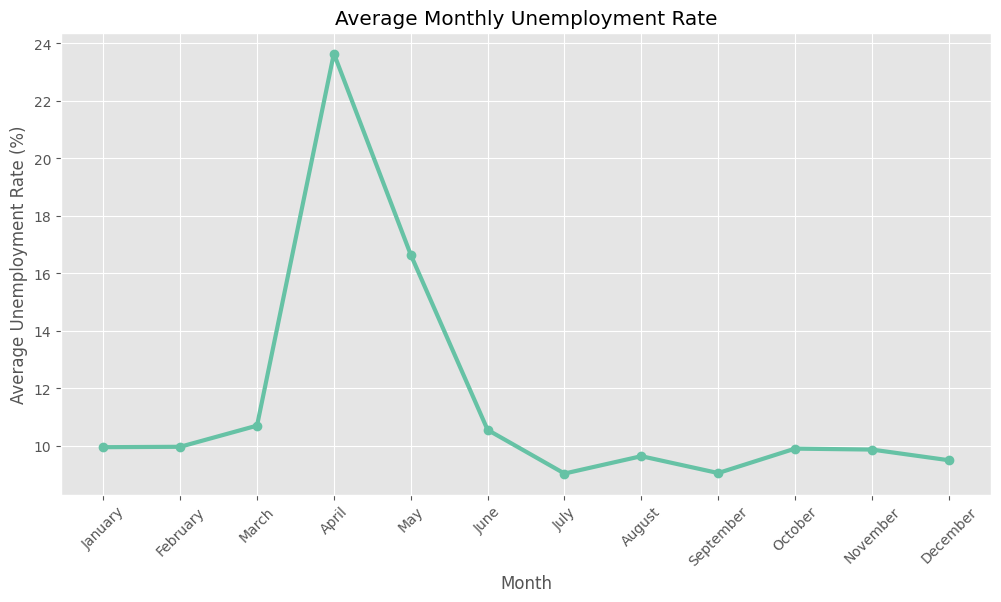

In [31]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o",
    linewidth=3
)

plt.xticks(rotation=45)

plt.title("Average Monthly Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(True)

plt.show()

In [32]:
# Urban vs Rural comparison

area_avg = df.groupby("Area")["Unemployment"].mean()

area_avg

Area
Rural    10.324791
Urban    13.166614
Name: Unemployment, dtype: float64

C:\Users\khush\AppData\Local\Temp\ipykernel_4968\48887773.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


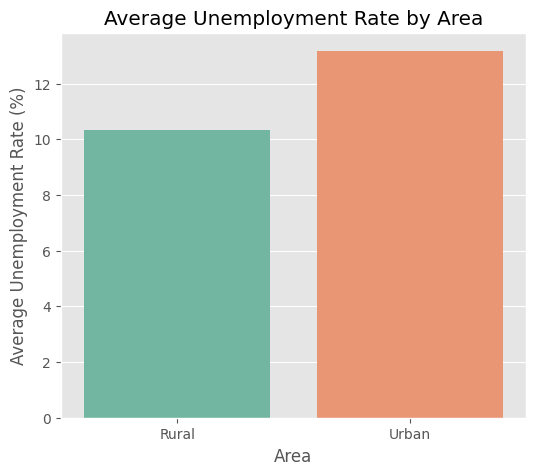

In [33]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=area_avg.index,
    y=area_avg.values,
    palette="Set2"
)

plt.title("Average Unemployment Rate by Area")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

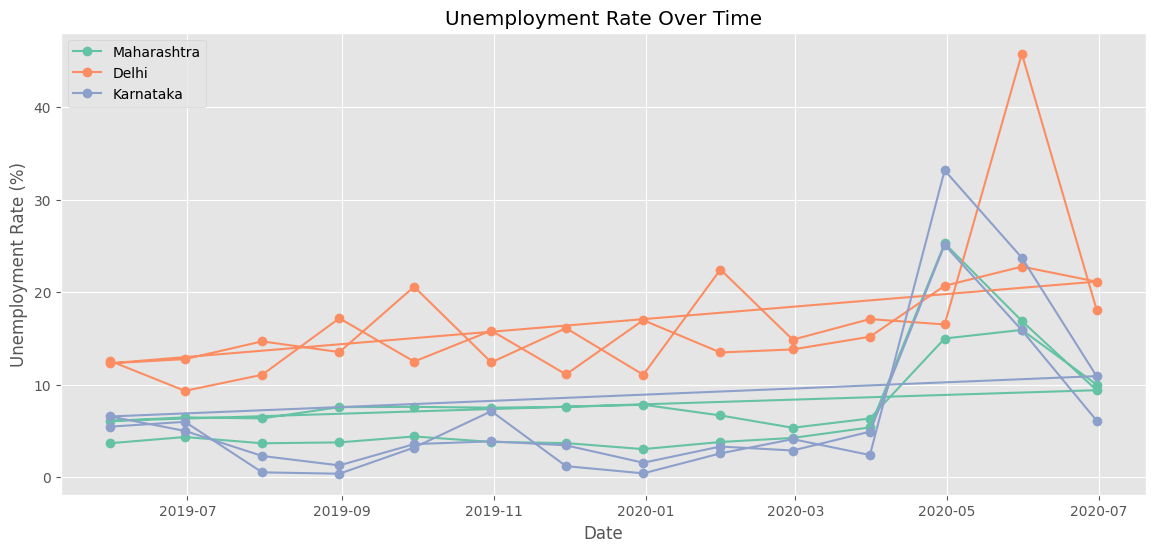

In [34]:
# Time-series analysis for three major states

states = ["Maharashtra", "Delhi", "Karnataka"]

plt.figure(figsize=(14,6))

for state in states:
    temp = df[df["Region"] == state]

    plt.plot(
        temp["Date"],
        temp["Unemployment"],
        marker="o",
        label=state
    )

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.legend()

plt.grid(True)

plt.show()

In [35]:
# Correlation matrix

corr = df[
    [
        "Unemployment",
        "Employed",
        "LabourParticipation"
    ]
].corr()

corr

,Unemployment,Employed,LabourParticipation
Unemployment,1.000000,-0.222876,0.002558
Employed,-0.222876,1.000000,0.011300
LabourParticipation,0.002558,0.011300,1.000000


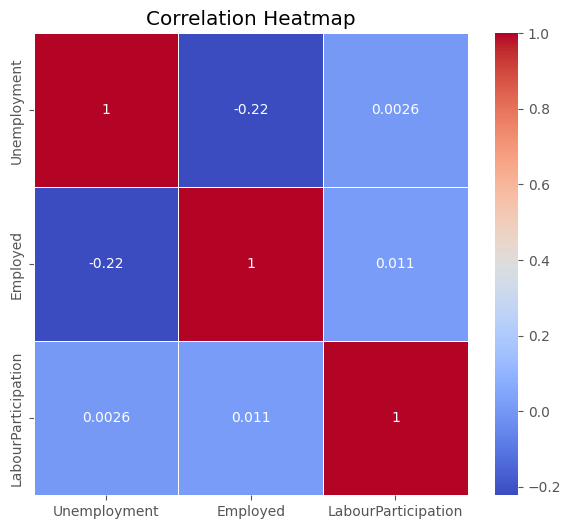

In [36]:
plt.figure(figsize=(7,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

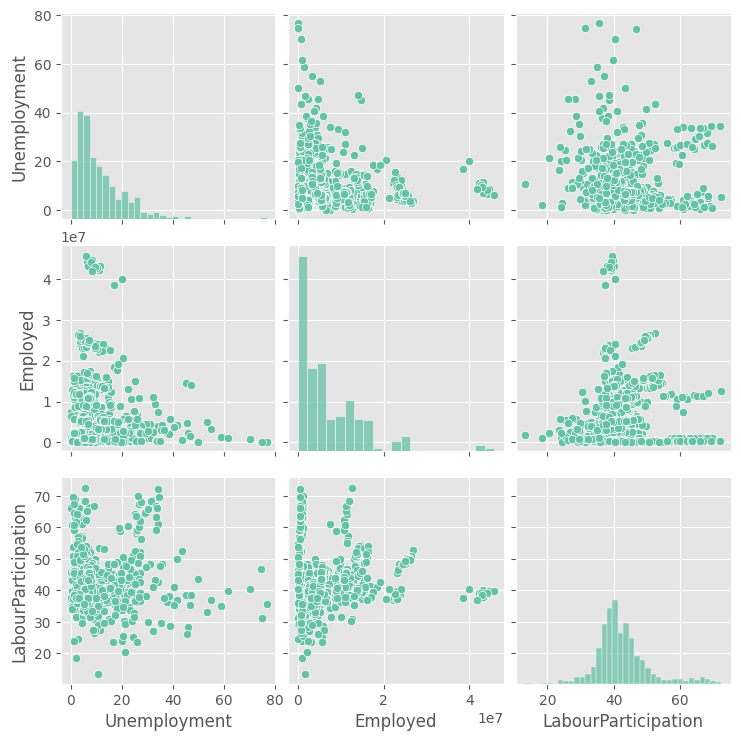

In [37]:
# Pairplot

sns.pairplot(
    df[
        [
            "Unemployment",
            "Employed",
            "LabourParticipation"
        ]
    ]
)

plt.show()

# COVID-19 Impact Analysis

The COVID-19 pandemic significantly affected employment across India.

In this section, the dataset is divided into two periods:

- **Pre-COVID:** Before March 2020
- **Post-COVID:** March 2020 onwards

The average unemployment rate for both periods is compared to understand the impact of the pandemic.

In [38]:
# Splitting the dataset into Pre-COVID and Post-COVID

pre_covid = df[df["Date"] < "2020-03-01"]

post_covid = df[df["Date"] >= "2020-03-01"]

## Creating Two Time Periods

The dataset has been divided into two separate periods based on the beginning of the nationwide COVID-19 lockdown in March 2020.

This allows us to compare unemployment before and after the pandemic.

In [39]:
# Average unemployment before COVID

pre_mean = pre_covid["Unemployment"].mean()

print("Average Unemployment Rate (Pre-COVID):")
print(round(pre_mean,2), "%")

Average Unemployment Rate (Pre-COVID):
9.51 %


## Observation

The calculated averages indicate how unemployment changed after the outbreak of COVID-19.

A higher post-COVID unemployment rate reflects the economic impact of lockdowns, business closures, and reduced industrial activities.

In [40]:
# Average unemployment after COVID

post_mean = post_covid["Unemployment"].mean()

print("Average Unemployment Rate (Post-COVID):")
print(round(post_mean,2), "%")

Average Unemployment Rate (Post-COVID):
17.77 %


## COVID Comparison Table

The table summarizes the average unemployment rate during the two time periods.

It provides a quick comparison of unemployment before and after the pandemic.

In [41]:
# Creating comparison dataframe

covid_df = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate": [pre_mean, post_mean]
})

covid_df

,Period,Average Unemployment Rate
0,Pre-COVID,9.509534
1,Post-COVID,17.774363


## Observation

The bar chart clearly demonstrates that unemployment increased during the COVID-19 period.

The pandemic caused widespread disruptions across industries, leading to job losses and increased unemployment throughout the country.

C:\Users\khush\AppData\Local\Temp\ipykernel_4968\3547550612.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


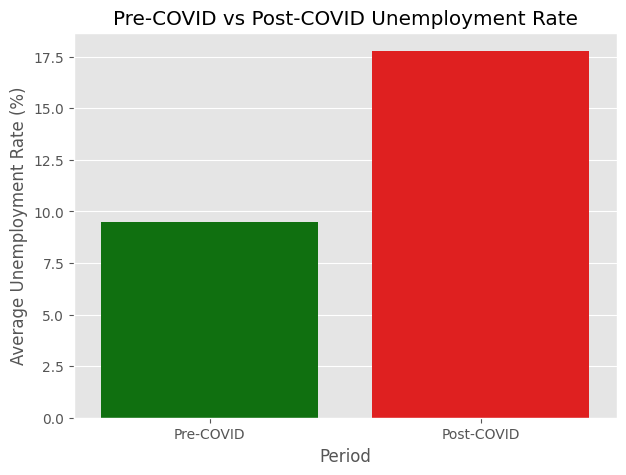

In [42]:
# COVID comparison bar chart

plt.figure(figsize=(7,5))

sns.barplot(
    data=covid_df,
    x="Period",
    y="Average Unemployment Rate",
    palette=["green", "red"]
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")

plt.xlabel("Period")

plt.ylabel("Average Unemployment Rate (%)")

plt.show()

## Highest Unemployment States

This analysis identifies the states with the highest average unemployment rates throughout the study period.

These regions may require stronger employment policies and economic development initiatives.

In [43]:
# Highest unemployment state

highest_state = df.groupby("Region")["Unemployment"].mean().sort_values(ascending=False)

highest_state.head()

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Name: Unemployment, dtype: float64

## Lowest Unemployment States

The states with the lowest unemployment rates indicate relatively better employment opportunities and economic stability compared to other regions.

In [44]:
# Lowest unemployment state

lowest_state = df.groupby("Region")["Unemployment"].mean().sort_values()

lowest_state.head()

Region
Meghalaya      4.798889
Odisha         5.657857
Assam          6.428077
Uttarakhand    6.582963
Gujarat        6.663929
Name: Unemployment, dtype: float64

In [45]:
# Highest employment states

employment = df.groupby("Region")["Employed"].mean().sort_values(ascending=False)

employment.head(10)

Region
Uttar Pradesh     2.809483e+07
Maharashtra       1.999020e+07
West Bengal       1.719854e+07
Bihar             1.236619e+07
Tamil Nadu        1.226955e+07
Gujarat           1.140201e+07
Madhya Pradesh    1.111548e+07
Karnataka         1.066712e+07
Rajasthan         1.004106e+07
Andhra Pradesh    8.154093e+06
Name: Employed, dtype: float64

In [46]:
# Display correlation values

corr

,Unemployment,Employed,LabourParticipation
Unemployment,1.000000,-0.222876,0.002558
Employed,-0.222876,1.000000,0.011300
LabourParticipation,0.002558,0.011300,1.000000


## Key Relationships

The correlation matrix indicates how unemployment, employment, and labour participation influence each other.

These relationships provide useful insights into the structure of the Indian labour market.

# Key Insights

The exploratory analysis provides several important insights regarding unemployment in India.

### Major Findings

- The unemployment rate varies significantly across different states.
- Some states consistently report higher unemployment than others.
- Monthly unemployment trends reveal noticeable fluctuations throughout the year.
- Urban and Rural areas experience different unemployment levels.
- Employment indicators show meaningful correlations.
- COVID-19 significantly increased unemployment across India.
- Time-series analysis shows that unemployment sharply increased during lockdown months before gradually declining.

# Conclusion

This project analyzed unemployment trends in India using Python and various data visualization techniques.

The analysis involved data cleaning, preprocessing, exploratory data analysis, time-series visualization, correlation analysis, and comparison of unemployment before and after the COVID-19 pandemic.

### Conclusion

- Regional unemployment differences are significant across India.
- Several states consistently experience higher unemployment rates.
- Monthly trend analysis indicates fluctuations influenced by economic conditions.
- COVID-19 had a substantial impact on unemployment, increasing joblessness across most states.
- Correlation analysis provided insights into relationships among unemployment, employment, and labour participation.

Overall, this project demonstrates how Python can be used to analyze real-world economic datasets and generate meaningful insights through data visualization and statistical analysis.

In [47]:
# Save cleaned dataset

df.to_csv("Cleaned_Unemployment_Data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
